This is just an exploratory data analysis of the combined texas oil data.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msn

In [31]:
df_cycle = pd.read_parquet("../../../data/raw/texas/pdq_lease_output/og_lease_cycle.parquet")
df_cycle.info()

<class 'pandas.DataFrame'>
RangeIndex: 31875640 entries, 0 to 31875639
Data columns (total 19 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   OIL_GAS_CODE            category      
 1   DISTRICT_NO             str           
 2   CYCLE_YEAR_MONTH        Int32         
 3   FIELD_NO                str           
 4   FIELD_TYPE              str           
 5   PROD_REPORT_FILED_FLAG  category      
 6   LEASE_OIL_PROD_VOL      float64       
 7   LEASE_CSGD_PROD_VOL     float64       
 8   LEASE_OIL_ALLOW         int64         
 9   LEASE_GAS_ALLOW         int64         
 10  LEASE_OIL_ENDING_BAL    int64         
 11  LEASE_COND_ENDING_BAL   int64         
 12  LEASE_GAS_LIFT_INJ_VOL  int64         
 13  LEASE_CSGD_GAS_LIFT     int64         
 14  LEASE_OIL_TOT_DISP      int64         
 15  LEASE_GAS_TOT_DISP      int64         
 16  LEASE_COND_TOT_DISP     int64         
 17  LEASE_CSGD_TOT_DISP     int64         
 18  PROD_DATE  

In [32]:
df_cycle.columns = df_cycle.columns.str.lower()
df_cycle.columns

Index(['oil_gas_code', 'district_no', 'cycle_year_month', 'field_no',
       'field_type', 'prod_report_filed_flag', 'lease_oil_prod_vol',
       'lease_csgd_prod_vol', 'lease_oil_allow', 'lease_gas_allow',
       'lease_oil_ending_bal', 'lease_cond_ending_bal',
       'lease_gas_lift_inj_vol', 'lease_csgd_gas_lift', 'lease_oil_tot_disp',
       'lease_gas_tot_disp', 'lease_cond_tot_disp', 'lease_csgd_tot_disp',
       'prod_date'],
      dtype='str')

In [35]:
df_cycle[['lease_gas_allow','lease_gas_lift_inj_vol','lease_gas_tot_disp','lease_csgd_gas_lift']].sum()

lease_gas_allow                    0
lease_gas_lift_inj_vol             0
lease_gas_tot_disp                 0
lease_csgd_gas_lift       3323007421
dtype: int64

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/matplotlib/image.py:183: UserWarning: Data with more than 2**24 rows cannot be accurately displayed. Downsampling to less than 2**24 rows before displaying. To remove this warning, manually downsample your data.
  warnings.warn(msg.format(n='2**24 rows'))


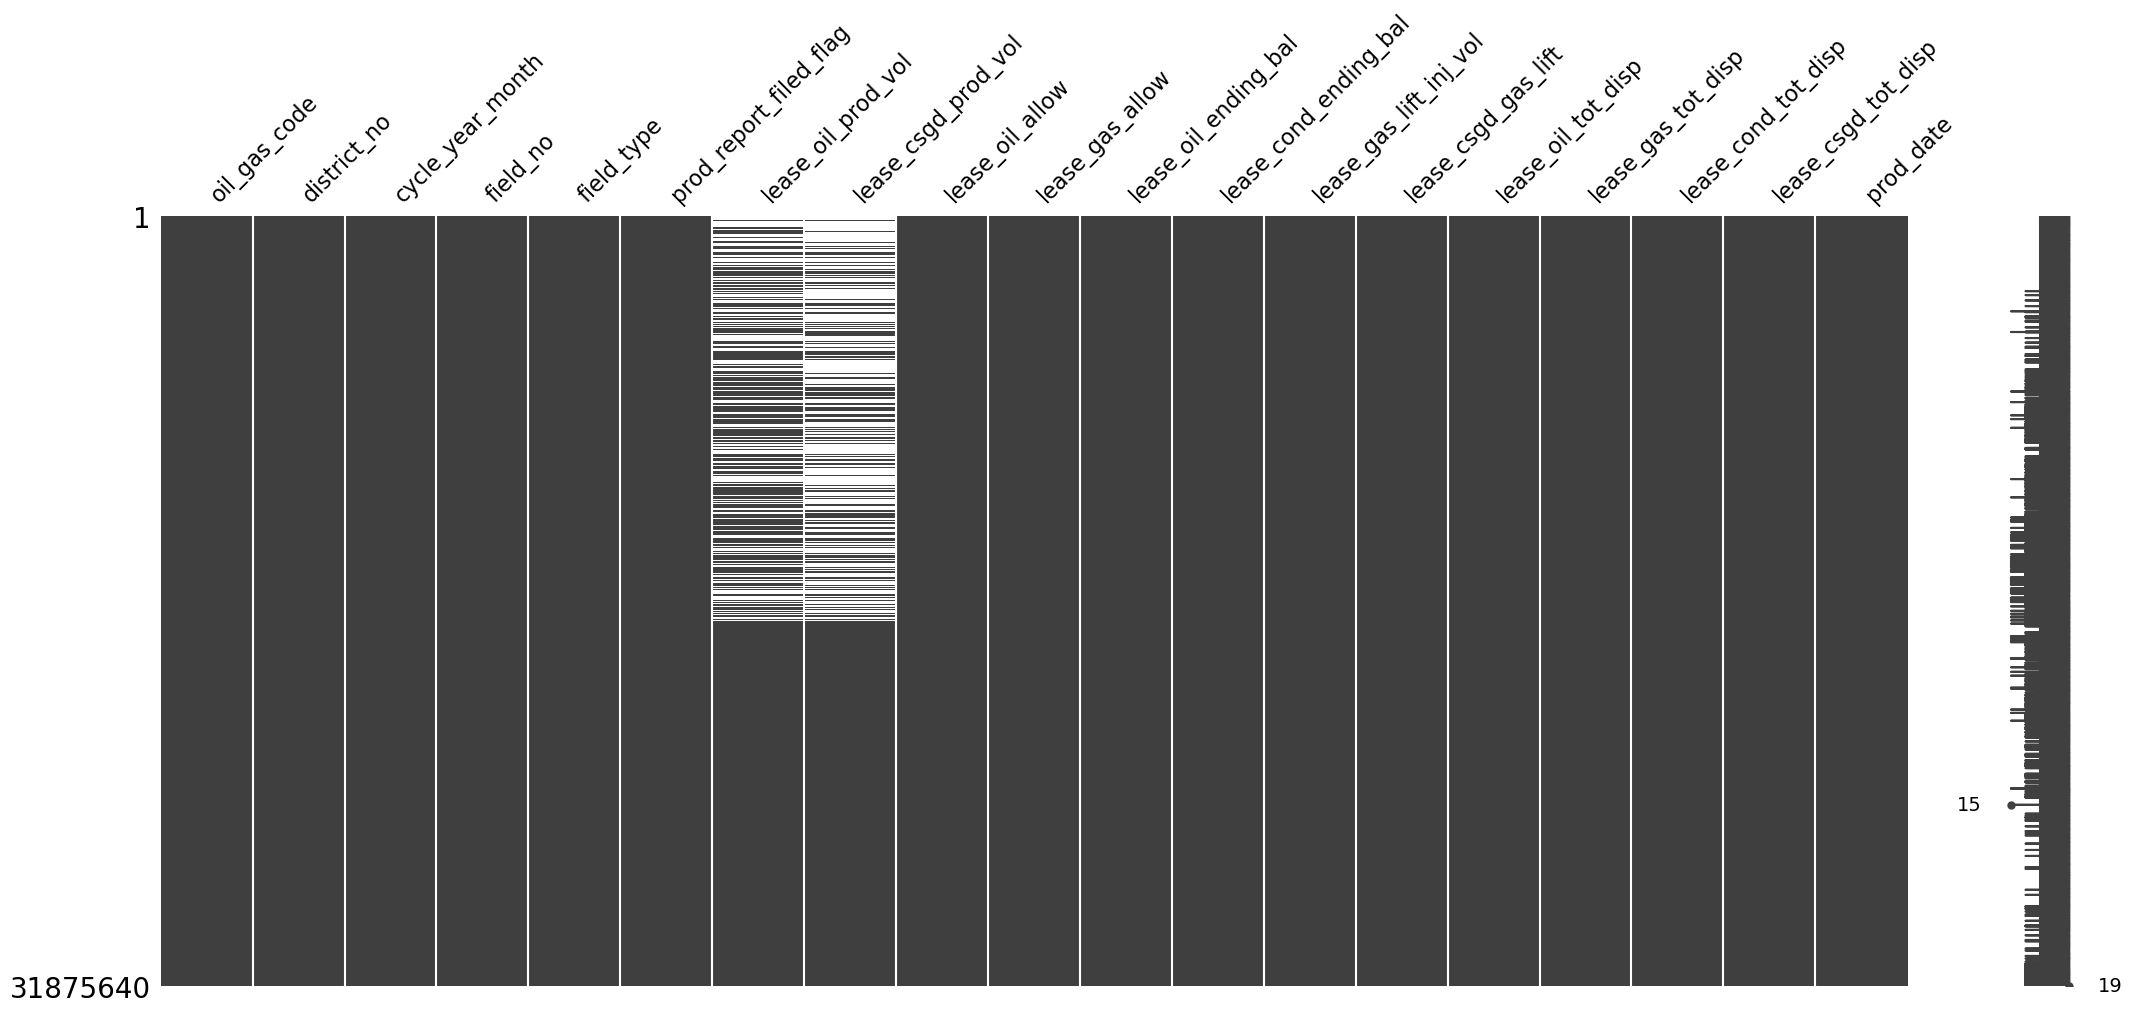

In [36]:
msn.matrix(df_cycle)
plt.show()

In [37]:
df_cycle = df_cycle.drop(columns = ['oil_gas_code','cycle_year_month','field_type','lease_gas_allow','lease_gas_lift_inj_vol','lease_gas_tot_disp'])

In [38]:
df_cycle.info()

<class 'pandas.DataFrame'>
RangeIndex: 31875640 entries, 0 to 31875639
Data columns (total 13 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   district_no             str           
 1   field_no                str           
 2   prod_report_filed_flag  category      
 3   lease_oil_prod_vol      float64       
 4   lease_csgd_prod_vol     float64       
 5   lease_oil_allow         int64         
 6   lease_oil_ending_bal    int64         
 7   lease_cond_ending_bal   int64         
 8   lease_csgd_gas_lift     int64         
 9   lease_oil_tot_disp      int64         
 10  lease_cond_tot_disp     int64         
 11  lease_csgd_tot_disp     int64         
 12  prod_date               datetime64[us]
dtypes: category(1), datetime64[us](1), float64(2), int64(7), str(2)
memory usage: 3.2 GB


In [ ]:
tot_vol = df_cycle.groupby(['prod_date']).lease_oil_prod_vol.sum()
tot_vol.index
tot_vol

prod_date
1993-01-01     50411016.0
1993-02-01     45634698.0
1993-03-01     50288153.0
1993-04-01     48194498.0
1993-05-01     49330060.0
                 ...     
2026-02-01    126320747.0
2026-03-01    132082778.0
2026-04-01            0.0
2026-05-01            0.0
2026-06-01            0.0
Name: lease_oil_prod_vol, Length: 402, dtype: float64

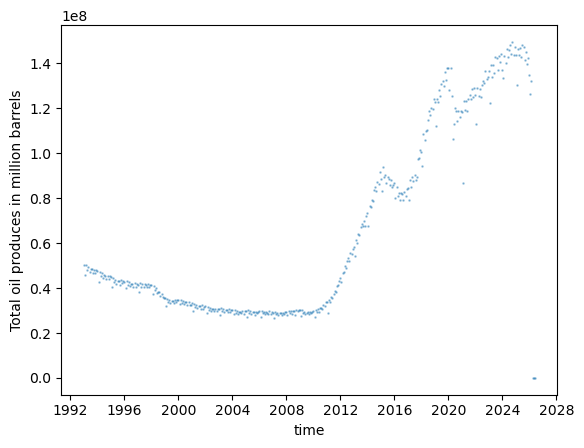

In [56]:
plt.scatter(vol.index,vol, alpha = 0.4, s = 0.7)
plt.xlabel('time')
plt.ylabel('Total oil produces in million barrels')
plt.show()